# Choose the Right Azure Foundry Tool for Document Processing

> *"These tools are not alternatives of each other — they are **lenses**. A new set of eyes with a specific use case. Each has its own intent, its own specialty. They can be used individually or together based on need."*

This notebook runs the **same document — `PeriodicTable.pdf`** — through all three Azure AI document processing approaches so you can see the fundamental difference between *seeing text*, *structuring content*, and *understanding meaning*.

## The Three Lenses

| **Azure AI Document Intelligence** | **Content Understanding (via DI)** | **Custom Model Deployments (Azure OpenAI)** |
|---|---|---|
| Extracts text, key-value pairs, tables, and layout structure with proven high-accuracy and consistency. It excels at processing standard forms (invoices, receipts, IDs, contracts) through OCR/Read/Layout models, prebuilt models, and custom models for field extraction and classification. Its core strengths are confidence scores, bounding-box grounding, and predefined schemas for templated documents — ideal when you need reliable extraction from documents with known structures. | Content Understanding is accessed through Document Intelligence's `output_content_format="markdown"` parameter. It provides enhanced semantic analysis including paragraph role classification (titles, headers, footers), figure detection, improved table handling with merged cells, and structured markdown output. Perfect for document modernization, content management systems, and scenarios requiring semantic understanding of document structure. | Provides maximum flexibility for developers who need fine-grained control over models, costs, and prompts using Azure OpenAI deployed models (GPT-4o, GPT-4, etc.). This approach offers complete freedom in model choice, prompt tuning, and workflow definition, making it perfect for agentic workflows, custom narrative generation, or experimental scenarios. However, it requires engineering investment in model upgrades, quality assurance, and reliability management. |

**In the sections below**, we'll run the same document through each service to demonstrate these differences hands-on, followed by guidance on choosing the right tool for your specific use case.

## Architecture

```
📄 PeriodicTable.pdf
        │
        ▼
🔍 Document Intelligence (di-demo-keys)
        │
        ├── 📄 OCR/Read → Clean text in reading order
        ├── 📊 Layout → Tables + paragraphs + grounding
        └── 🧠 Content Understanding → Semantic roles + figures (via markdown output)

Optional: ✨ Azure OpenAI (gpt-4o) → Custom vision analysis
```

## Prerequisites
- **Azure Document Intelligence** resource:
  - FormRecognizer (Document Intelligence) resource
  - Custom subdomain enabled (required for token authentication)
  - Location: eastus (or your preferred region)
- **Azure CLI** installed and authenticated (`az login`)
- `PeriodicTable.pdf` is already in this folder

> **Note:** This notebook uses Azure CLI token authentication (no API keys needed). Content Understanding features are accessed through Document Intelligence's `output_content_format="markdown"` parameter. Optional: Azure OpenAI resource for custom model deployments (Cell 13).

In [ ]:
# Cell 2: Install dependencies (no azure-identity needed - we'll use Azure CLI tokens)
%pip install azure-ai-documentintelligence azure-core openai pandas requests Pillow

## Azure Resource Setup

<details>
<summary><b>Click to expand setup instructions</b> (skip if resources already configured)</summary>

### Current Setup
✅ **Resource Group:** `rg-doc-processing-demo`  
✅ **Document Intelligence:** `di-demo-keys` (with custom subdomain for token auth)  
✅ **Authentication:** Azure CLI Bearer Token  

### To Replicate:

```bash
az login
az group create --name rg-doc-processing-demo --location eastus
az cognitiveservices account create \
  --name di-demo-keys \
  --resource-group rg-doc-processing-demo \
  --kind FormRecognizer --sku S0 --location eastus \
  --custom-domain di-demo-keys --yes
az account get-access-token --resource https://cognitiveservices.azure.com --query accessToken -o tsv
```

</details>

In [ ]:
# Cell 3: Configuration with Azure CLI token
# Note: Token obtained from Azure CLI (expires in ~1 hour)
# To refresh: az account get-access-token --resource https://cognitiveservices.azure.com --query accessToken -o tsv

# ── Azure Resource Configuration ───────────────────────────────────────────────
RESOURCE_GROUP = "rg-doc-processing-demo"

# Access token from Azure CLI
# Run this command to get a fresh token: 
# az account get-access-token --resource https://cognitiveservices.azure.com --query accessToken -o tsv
ACCESS_TOKEN = "YOUR_ACCESS_TOKEN_HERE"  # Replace with your token from az login

print("✅  Access token configured (valid for ~1 hour)")

# ── Document Intelligence Configuration ────────────────────────────────────────
# Document Intelligence resource with custom subdomain (required for token authentication)
DI_RESOURCE = "di-demo-keys"
DI_ENDPOINT = "https://di-demo-keys.cognitiveservices.azure.com/"

# Local document path
DOCUMENT_PATH = "PeriodicTable.pdf"

print("\n📋 Configuration:")
print(f"   Resource Group : {RESOURCE_GROUP}")
print(f"   DI Resource    : {DI_RESOURCE}")
print(f"   DI Endpoint    : {DI_ENDPOINT}")
print(f"   Document       : {DOCUMENT_PATH}")
print(f"\n🔐 Using Azure CLI token authentication")
print(f"\n💡 Content Understanding accessed via Document Intelligence")
print(f"    (using output_content_format='markdown' parameter)")


✅  Access token configured (valid for ~1 hour)

📋 Configuration:
   Resource Group : rg-doc-processing-demo
   DI Resource    : di-demo-keys
   DI Endpoint    : https://di-demo-keys.cognitiveservices.azure.com/
   Document       : PeriodicTable.pdf

🔐 Using Azure CLI token authentication


In [3]:
# Cell 4: Initialize Document Intelligence client

from azure.ai.documentintelligence import DocumentIntelligenceClient
from collections import namedtuple
import time

# Simple token credential wrapper for Azure CLI token
class TokenCredential:
    def __init__(self, token):
        self.token = token
        self.expires_on = int(time.time()) + 3600  # Token valid for 1 hour
    
    def get_token(self, *scopes, **kwargs):
        Token = namedtuple('Token', ['token', 'expires_on'])
        return Token(token=self.token, expires_on=self.expires_on)

credential = TokenCredential(ACCESS_TOKEN)

di_client = DocumentIntelligenceClient(endpoint=DI_ENDPOINT, credential=credential)

print("✅  Document Intelligence client initialized")
print(f"   Endpoint: {DI_ENDPOINT}")
print(f"\n✅ Ready to process documents!")

✅  Document Intelligence client initialized
   Endpoint: https://di-demo-keys.cognitiveservices.azure.com/

✅ Ready to process documents!


In [4]:
# Cell 5: Verify document exists
# Note: PyMuPDF not available on Windows ARM64, skipping visual preview
import os

if os.path.exists(DOCUMENT_PATH):
    file_size_kb = os.path.getsize(DOCUMENT_PATH) / 1024
    print(f"✅  Document found: {DOCUMENT_PATH}")
    print(f"    Size: {file_size_kb:.1f} KB")
    print(f"\n📄 Ready to process through all three services!")
else:
    print(f"❌  Document not found: {DOCUMENT_PATH}")
    print(f"    Please ensure PeriodicTable.pdf is in the current directory")
    raise FileNotFoundError(DOCUMENT_PATH)

✅  Document found: PeriodicTable.pdf
    Size: 152.5 KB

📄 Ready to process through all three services!


## Tool 1: Document Intelligence

Document Intelligence is the **perception** layer — a specialized, single-pass system trained to faithfully describe *what it sees* on a page: characters, words, lines, tables, and spatial regions.

### Three layers of perception

| Model | What it extracts | When to use |
|---|---|---|
| **OCR / Read** | Clean text in reading order | Full-text search, RAG chunking, compliance audit logs |
| **Layout** | Paragraphs, tables, columns, figures, selection marks | Structure-aware chunking, multi-column documents |
| **Prebuilt** (Invoice, Receipt, ID…) | Named fields + confidence + bounding-box grounding | Standard templated documents with known schemas |

> **Key characteristic:** Document Intelligence does not *infer*. If a field is not structurally present on the page, it will not guess it. That predictability and grounding is also its greatest strength.

The next three cells each run a different level of Document Intelligence on `PeriodicTable.pdf` — progressing from raw text → geometric structure → field extraction.

### 1.1 OCR / Read

In [9]:
# Cell 7: Document Intelligence — OCR / Read
# Extracts clean text in reading order — ideal for search indexing and RAG ingestion.

from azure.ai.documentintelligence.models import AnalyzeDocumentRequest

with open(DOCUMENT_PATH, "rb") as f:
    document_bytes = f.read()

poller = di_client.begin_analyze_document(
    "prebuilt-read",
    body=document_bytes,
    content_type="application/pdf"
)

result = poller.result()

full_text = "\n".join(
    line.content
    for page in result.pages
    for line in (page.lines or [])
)

print(f"Pages : {len(result.pages)}")
print(f"Lines : {sum(len(page.lines or []) for page in result.pages)}")
print(f"Chars : {len(full_text)}")
print(f"\n── Extracted text (first 500 chars) ──")
print(full_text[:500])

Pages : 1
Lines : 194
Chars : 873

── Extracted text (first 500 chars) ──
Periodic Table: [ion fission pool simulator]
CHARGE SIZES
40.
He
39.
H2
He
35
H2
H2
He
32
H2
H2
H2
He
30
H2
H2
H2
H2
He
28.
Na+ H2
H2
H2
H2
He
26
Na+ Na+
H2
H2
H2
H2
He
24
Na+ Na+ Na+ H2
H2
H2
H2
He
22.
Na+ Na+ Na+ Na+ H2
H2
H2
H2
He
20
Na+ Na+ Na+ Na+ Na+
H2
H2
H2
H2
He
19
Na+ Na+ Na+ Na+ Na+
Na+ H2
H2
H2
H2
He
9
Na+ Na+ Na+ Na+ Na+ Na+ Na+
H2
H2
H2
H2
H2
H2
He
3
Na+ Na+ Na+ Na+ Na+ Na+ Na+ Na+ Na+ Na+ Na+
H2
He
2
Na+ Na+ Na+ Na+ Na+ Na+ Na+ Na+
He
1.
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
Mg
M


---

**📸 Portal Screenshot**

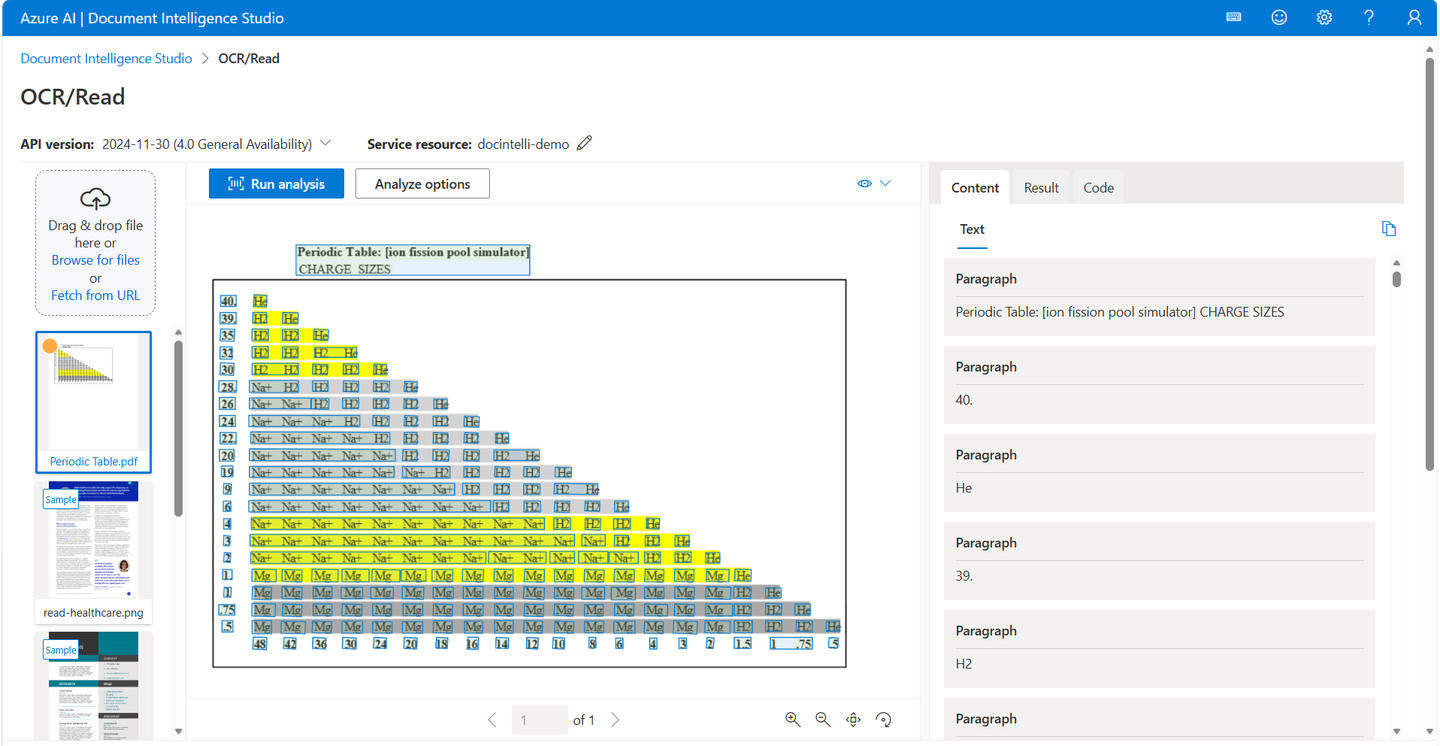
---

### 1.2 Layout

In [10]:
# Cell 8: Document Intelligence — Layout
# Detects tables, columns, and page regions; renders tables as pandas DataFrames.

import pandas as pd

with open(DOCUMENT_PATH, "rb") as f:
    document_bytes = f.read()

poller = di_client.begin_analyze_document(
    "prebuilt-layout",
    body=document_bytes,
    content_type="application/pdf"
)

layout_result = poller.result()
tables = layout_result.tables or []

print(f"Tables found   : {len(tables)}")
print(f"Paragraphs     : {len(layout_result.paragraphs or [])}")

def di_table_to_df(table) -> pd.DataFrame:
    """Reconstruct a DI table into a pandas DataFrame."""
    grid = [[""] * table.column_count for _ in range(table.row_count)]
    for cell in (table.cells or []):
        grid[cell.row_index][cell.column_index] = cell.content
    return pd.DataFrame(grid[1:], columns=grid[0]) if len(grid) > 1 else pd.DataFrame(grid)

for i, table in enumerate(tables[:2]):   # show first two tables
    print(f"\n── Table {i+1}: {table.row_count} rows × {table.column_count} cols ──")
    df = di_table_to_df(table)
    print(df.to_string(index=False, max_rows=8))

Tables found   : 1
Paragraphs     : 251

── Table 1: 21 rows × 21 cols ──
40. He                                                                       
39. H2             He                                                        
 35 H2             H2 He                                                     
 32 H2             H2 H2 He                                                  
 30 H2             H2 H2 H2 He                                               
 .. ..            ... .. .. .. .. .. .. .. .. .. .. .. .. .. ..  .. ..  .. ..
  1 Mg             Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg  H2 He       
.75 Mg Mg\n:selected: Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg  H2 H2  He   
 .5 Mg             Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg Mg  H2 H2  H2 He
    48             42 36 30 24 20 18 16 14 12 10  8  6  4  3  2 1.5  1 .75 .5


---

**📸 Portal Screenshot**

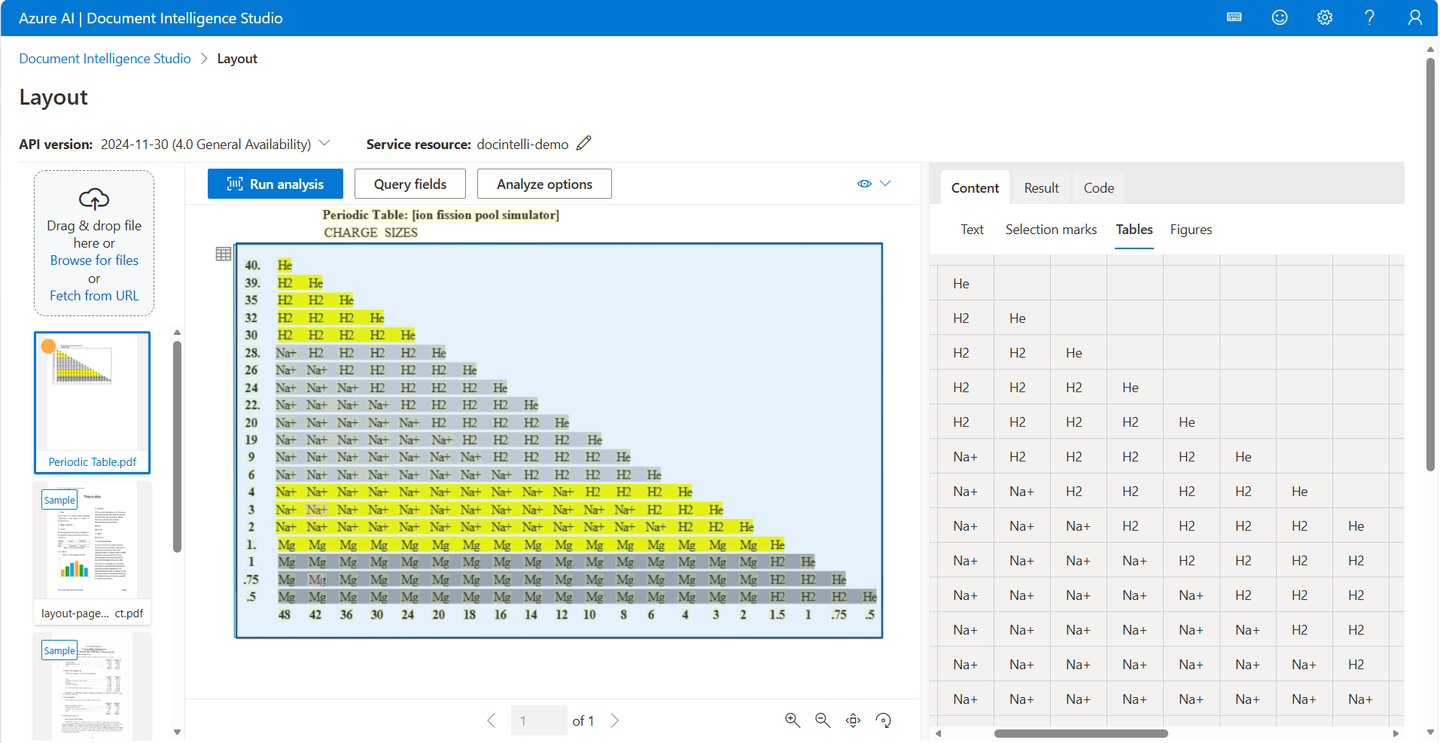

---

### Document Intelligence — Best Practices

**✅ Do:**
- Use **prebuilt models** for standard document types (invoice, receipt, ID, tax forms) — they're optimized and validated
- Leverage **confidence scores** to route low-confidence extractions to human review
- Use **bounding boxes** (grounding) for downstream validation or UI highlighting
- Choose **Read** for RAG pipelines where you only need text; Layout adds latency
- Batch process documents asynchronously for high-volume scenarios

**❌ Avoid:**
- Expecting inference — DI extracts what's *visible*, not what's *implied*
- Using Layout for simple text extraction (Read is faster)
- Ignoring confidence scores — they're your quality signal
- Processing single-page documents with custom models (prebuilts likely sufficient)

**Common pitfall:** Trying to extract fields that don't appear in the document (e.g., "payment status" when the invoice only shows amount due). DI will return empty or low-confidence results. For inference, use Content Understanding.

**Performance tip:** For multi-page documents, enable `pages` parameter to process specific pages only, reducing latency and cost.

## Tool 2: Content Understanding (via Document Intelligence)

Content Understanding is accessed through Document Intelligence's **markdown output format**. It provides enhanced semantic analysis by identifying paragraph roles, detecting figures, and outputting structured markdown.

Instead of just extracting raw text and tables, Content Understanding adds a **semantic understanding layer** that classifies content by purpose (titles, headers, footers, page numbers) and produces markdown output suitable for document modernization and content management systems.

### What sets it apart

| Capability | Standard DI (Read/Layout) | Content Understanding (Markdown) |
|---|---|---|
| Extracts text | ✅ | ✅ |
| Table detection | ✅ | ✅ Enhanced with colspan/rowspan |
| Paragraph role classification | ❌ | ✅ (title, header, footer, etc.) |
| Figure detection | Limited | ✅ |
| Structured output format | Text/JSON | ✅ Markdown with semantic HTML |
| Enhanced table handling | Basic | ✅ Merged cells properly handled |
| Semantic understanding | ❌ | ✅ |

> Content Understanding is ideal for scenarios requiring semantic document structure, such as converting legacy documents to markdown, integrating with content management systems, or processing documents with varying layouts.

Content Understanding is accessed via the **same Document Intelligence endpoint** using `output_content_format="markdown"` — no separate service or model deployment required. This makes it simple to add semantic understanding to your existing Document Intelligence workflows.

In [8]:
# Cell 11: Content Understanding — Enhanced Layout Analysis with Markdown Output
# Content Understanding is built into Document Intelligence - it provides advanced features like:
# • Markdown output format for semantic structure
# • Figure extraction and description
# • Enhanced table understanding with merged cells
# • Paragraph role classification (title, section heading, page header, etc.)

with open(DOCUMENT_PATH, "rb") as f:
    document_bytes = f.read()

# Use prebuilt-layout with markdown output format for Content Understanding capabilities
poller = di_client.begin_analyze_document(
    "prebuilt-layout",
    body=document_bytes,
    content_type="application/pdf",
    output_content_format="markdown"  # This enables Content Understanding features
)

cu_result = poller.result()

# Extract markdown output (Content Understanding feature)
markdown_content = cu_result.content if hasattr(cu_result, 'content') else ""

print(f"📊 Content Understanding Analysis Results:")
print(f"   Pages      : {len(cu_result.pages)}")
print(f"   Tables     : {len(cu_result.tables or [])}")
print(f"   Paragraphs : {len(cu_result.paragraphs or [])}")
print(f"   Figures    : {len(cu_result.figures or [])}")

if cu_result.paragraphs:
    # Show paragraph role classification (Content Understanding feature)
    roles = {}
    for para in cu_result.paragraphs:
        role = para.role if hasattr(para, 'role') and para.role else 'content'
        roles[role] = roles.get(role, 0) + 1
    print(f"\n📝 Paragraph roles detected:")
    for role, count in roles.items():
        print(f"   • {role}: {count}")

print(f"\n── Markdown output (first 600 chars) ──")
print(markdown_content[:600] if markdown_content else "No markdown content available")

print("\n✅ Content Understanding features demonstrated:")
print("   • Structured markdown output")
print("   • Paragraph role classification")
print("   • Enhanced table understanding")
print("   • Figure detection and extraction")

📊 Content Understanding Analysis Results:
   Pages      : 1
   Tables     : 1
   Paragraphs : 251
   Figures    : 1

📝 Paragraph roles detected:
   • ParagraphRole.TITLE: 1
   • content: 250

── Markdown output (first 600 chars) ──
# Periodic Table: [ion fission pool simulator] CHARGE SIZES


<table>
<tr>
<th>40.</th>
<th colspan="2">He</th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
<th></th>
</tr>
<tr>
<td>39.</td>
<td>H2</td>
<td>He</td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
<td></td>
</tr>
<tr>
<td>35</td>
<td>H2</td>
<td>H2</td>
<td>He</td>
<td></td>
<td></td>
<

✅ Content Understanding features demonstrated:
   • Structured markdown output
   • Paragraph role classification
   • Enhanced table understanding
   • Figure detect

---

**📸 Portal Screenshot**

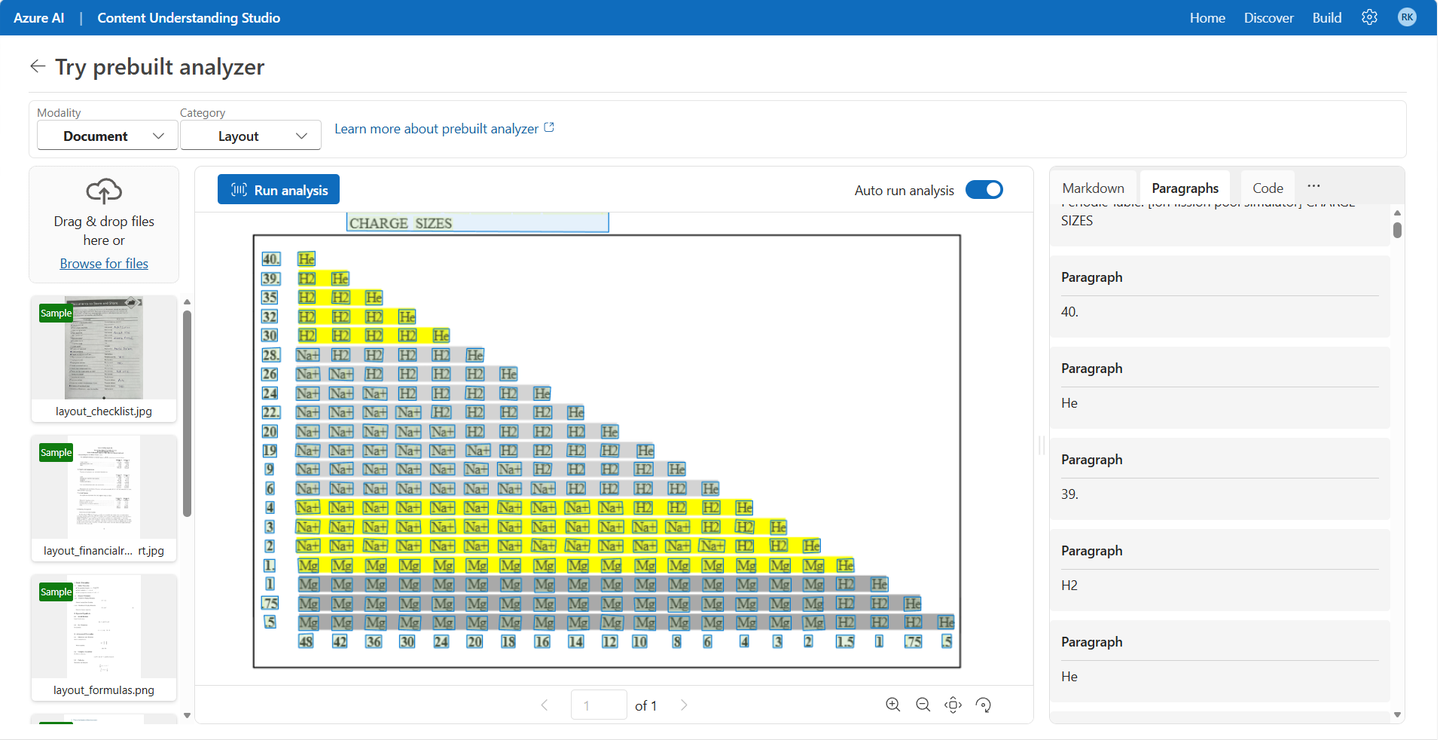

---

### Content Understanding — Best Practices

**✅ Do:**
- Use `output_content_format="markdown"` to enable Content Understanding features
- Leverage **semantic paragraph roles** (title, header, footer) for document classification
- Use **figure detection** for documents with charts, diagrams, or images
- Apply **enhanced table handling** for complex tables with merged cells
- Export to **markdown** for document modernization workflows

**❌ Avoid:**
- Using Content Understanding for simple text extraction (standard Read is faster)
- Ignoring paragraph role classification — it's valuable for document structure analysis

**Best use cases:** Document modernization, content management systems, varying document layouts, semantic structure extraction.

## Tool 3: Foundry Model Deployments — Build Your Own Solution

Using Foundry-deployed models (GPT-4o, GPT-4.1, etc.) directly gives you **maximum flexibility**. You write the prompt, you choose the model version, you define the output format. There is no managed pipeline — every design decision is yours.

### When this is the right choice
- You need **conversational or narrative output**, not just structured field extraction
- You need **full control** over model version, prompt design, and cost
- You are building an **agentic workflow** where the document is one step in a larger pipeline
- The document type doesn't fit any prebuilt schema and you need rapid experimentation

### Trade-offs vs managed services

| | Managed (DI / CU) | Build Your Own (Foundry Models) |
|---|---|---|
| Confidence scores | ✅ Built-in | ❌ Custom implementation required |
| Source grounding | ✅ Built-in | ❌ Custom implementation required |
| Prompt engineering | Automatic | Manual — full control |
| Model upgrades | Managed by Microsoft | **Your responsibility** |
| Latency | Predictable, low | Depends on PTUs / token load |
| Multimodal support | CU only | ✅ With vision-capable models |



> The combination that often works best in production: **Content Understanding for structured field extraction → Foundry model deployments for downstream reasoning, narrative generation, or agentic decisions.**

In [13]:
# Cell 13: Azure OpenAI (Optional) — Custom Document Analysis Example

# Example: Using Azure OpenAI with vision for custom document analysis
# Uncomment and configure to use:

# from openai import AzureOpenAI
# import base64

# client = AzureOpenAI(
#     azure_endpoint="https://<your-resource>.openai.azure.com/",
#     api_key="<your-api-key>",
#     api_version="2024-12-01-preview"
# )

# with open("PeriodicTable.pdf", "rb") as f:
#     pdf_base64 = base64.b64encode(f.read()).decode('utf-8')

# response = client.chat.completions.create(
#     model="gpt-4o",  # Your deployment name
#     messages=[
#         {"role": "system", "content": "You are a document analysis expert."},
#         {"role": "user", "content": [
#             {"type": "text", "text": "Extract all text from this table and format as JSON."},
#             {"type": "image_url", "image_url": {"url": f"data:application/pdf;base64,{pdf_base64}"}}
#         ]}
#     ]
# )

# print(response.choices[0].message.content)

print("💡 Azure OpenAI provides full control over prompts, models, and outputs")
print("📚 Docs: https://learn.microsoft.com/azure/ai-services/openai/")

💡 Azure OpenAI provides full control over prompts, models, and outputs
📚 Docs: https://learn.microsoft.com/azure/ai-services/openai/


## Choosing the Right Lens — Decision Guide

```
Primary goal?
│
├─ Extract raw text in reading order
│     → Document Intelligence — OCR / Read
│       (search indexing, RAG chunking, compliance audit logs)
│
├─ Detect tables and columns accurately
│     → Document Intelligence — Layout
│       (structure-aware chunking, multi-column documents)
│
├─ Parse a known standard form type (invoice, receipt, ID, tax form)
│     → Document Intelligence — Prebuilt Model
│       (domain-specific named fields, confidence + grounding out of the box)
│
├─ Handle many template variations or unstructured documents
│     → Content Understanding ✅ Recommended
│       (high-variation docs, complex layouts, zero labeling to start)
│
├─ Infer fields not explicitly printed in the document
│     → Content Understanding
│       (derived totals, inferred dates, jurisdiction from party addresses)
│
├─ Process images, audio, or video alongside documents
│     → Content Understanding
│       (unified multimodal pipeline, single API)
│
└─ Need full model / prompt / cost control or building an agent
      → Azure OpenAI (Foundry Models)
        (agentic workflows, narrative output, experimental scenarios)
```

### Microsoft's recommendation — scenario map

| Service | What it Does | Ideal For | Strengths | Core Features |
|---|---|---|---|---|
| **Document Intelligence** | Extracts text, key-value pairs, tables, and layout (structure) from documents, field extraction with grounding, confidence, support for classification and splitting | Standard forms, invoices, receipts, purchase orders, IDs, contracts, legal documents | Proven, high-accuracy extraction, consistency, confidence score and grounding, predefined schemas for many templated document types | OCR/Read/Layout models, Prebuilt Models (invoice, tax, receipt, etc.), Custom model (field extraction and classification) |
| **Content Understanding** | Processes documents, images, audio, and video; richer field extraction and inference, built-in support for validation, enrichment, and post processing, integrated reasoning for complex tasks (preview) | Complex document processing requiring extractive and inferred fields, document formats with large number of complex variations or truly unstructured documents, inferring, summarization and generate metadata | Built-in unified process for multimodal inputs; start with no labeling. Handles varying templates and unstructured documents, supports continuous improvement with labeled samples | Enhanced support for content extraction (OCR, layout), field extraction, inferred fields and classification, tackle large documents with high variations, configure your Gen AI model for control over quality and price. |
| **Build your own solution with Azure OpenAI Service** | Build a solution with any Azure-hosted LLM models, Fully control on model, prompt, and tools | Developers aiming to build, own, and manage a solution that requires fine grained control on models, costs, and prompts | Maximum flexibility and control | Multiple options to plug and play with model choice, prompt tuning, workflow definition with complete flexibility in building each component. Requires engineering investment in model upgrades, quality, and reliability. |

---

### References
- [Choose the right Foundry tool — Microsoft Docs](https://learn.microsoft.com/en-us/azure/ai-services/content-understanding/choosing-right-ai-tool)
- [Azure AI Document Intelligence](https://learn.microsoft.com/en-us/azure/ai-services/document-intelligence/)
- [Azure AI Content Understanding](https://learn.microsoft.com/en-us/azure/ai-services/content-understanding/)
- [Azure OpenAI Service](https://learn.microsoft.com/en-us/azure/ai-services/openai/)